## K Means
This will be a brief notebook about the K-Means clustering algorithm. The algorithm is used to cluster similar data points together without any labels. Due to its indifference to 
labels this is a form of unsupervised learning. The basic intuition behind the algorithm is that we select a number, $k$, that represents the number of clusters we have. 
Each of the $k$ centroid (center of the cluster) is initialized randomly to some point. Then we repeat the following 2 steps until convergence:
- The points get labeled according to which centroid they are closest t
- The centroid is moved to the center (mean) of all the points in the cluster 

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.widgets import Slider

In [2]:
rng = np.random.default_rng(seed=42)

class KMeans():
    def __init__(self, k, x_size):
        self.k = k
        self.centroids = rng.random(k*x_size).reshape(k,x_size)
        
    def _euclidean_distance(self,x1,x2):
        return np.sum((x1 - x2)**2, axis = 1)
        
    def _find_closest_centroid(self,x):
        return np.argmin(self._euclidean_distance(x,self.centroids))
        
    def _label_data(self, X):
        labels = np.apply_along_axis(self._find_closest_centroid,1,X) # this could be optimized to use vectorization, I just couldn't figure out how to
        return labels
    
    def _update_centroids(self, X, labels):
        avgs = np.array([np.mean(X[labels==i],axis=0) for i in range(self.k)])
        self.centroids = avgs
        
    def fit(self,X, epochs=100):
        for _ in range(epochs):
            labels = self._label_data(X)
            self._update_centroids(X,labels)

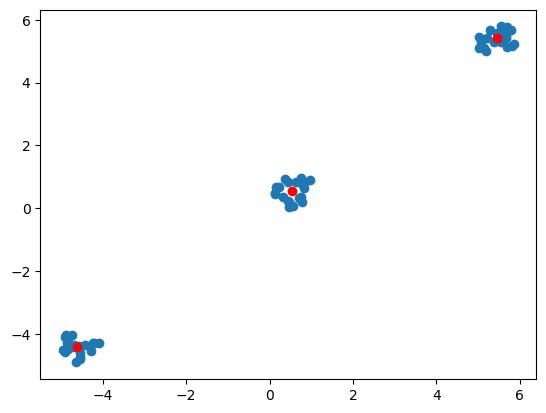

In [3]:
k = 3
m = 2

foo = KMeans(k,m)

X1 = rng.random((20,m))
X2 = rng.random((20,m)) + 5
X3 = rng.random((20,m)) - 5
X = np.vstack((X1,X2,X3))

foo.fit(X)

plt.scatter(X[:,0],X[:,1])
plt.scatter(foo.centroids[:,0],foo.centroids[:,1],c="red")